# Day 10 / 30 — Hybrid features: TF-IDF + spaCy linguistics

**Project:** 6-class news article categorisation  
**Stack:** scikit-learn · TF-IDF · spaCy · `ColumnTransformer`  
**Prerequisite:** `data/news_*_clean.parquet` from Day 8 (same as Day 9).

---

## What we build today

| Step | What | Why |
|------|------|-----|
| 1 | `ColumnTransformer`: TF-IDF on `text_clean` + `SpacyFeatureExtractor` on raw `text` | Bag-of-words + dense NER/POS/surface stats |
| 2 | `StandardScaler` on the dense branch | Put linguistic features on comparable scale before `LinearSVC` |
| 3 | Compare hybrid vs Day 9–style TF-IDF-only pipeline | Quantify lift from linguistics |
| 4 | Same stratified 5-fold CV + test metrics | Apples-to-apples with Day 9 |

---

## Why two text columns?

- **`text_clean`** (Day 8): lemmatised, stopwords removed — ideal input for **TF-IDF** vocabulary.
- **`text` (raw)**: full tokens and sentence boundaries for spaCy’s **tagger + NER** — `SpacyFeatureExtractor` runs the standard `en_core_web_sm` pipeline (you can switch to `en_core_web_md` if installed for slightly richer vectors; features here are still rule-based counts/ratios).

This is the standard **early fusion** pattern: `scipy.sparse.hstack` of sparse TF-IDF + scaled dense features inside sklearn’s `ColumnTransformer`.

## 0. Setup & imports

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, str(Path('..').resolve()))

N_JOBS = int(os.environ.get('SKLEARN_N_JOBS', '-1'))

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('..') / 'data'
TRAIN_PQ = DATA_DIR / 'news_train_clean.parquet'
TEST_PQ = DATA_DIR / 'news_test_clean.parquet'

print('Setup complete ✓')

Setup complete ✓


## 1. Load data

In [2]:
if not TRAIN_PQ.is_file() or not TEST_PQ.is_file():
    raise FileNotFoundError(
        f'Expected {TRAIN_PQ} and {TEST_PQ}. Run day8 through the parquet save step first.'
    )

df_train = pd.read_parquet(TRAIN_PQ)
df_test = pd.read_parquet(TEST_PQ)

for c in ('text', 'text_clean', 'label'):
    assert c in df_train.columns, f'missing column: {c}'

X_train_df = df_train[['text_clean', 'text']].copy()
X_test_df = df_test[['text_clean', 'text']].copy()

le = LabelEncoder()
y_train = le.fit_transform(df_train['label'])
y_test = le.transform(df_test['label'])
class_names = le.classes_

print(f'Train {len(df_train):,} | Test {len(df_test):,}')
print('Classes:', list(class_names))

Train 3,284 | Test 2,183
Classes: ['HEALTH', 'LIFESTYLE', 'POLITICS', 'SCIENCE', 'SPORTS', 'TECHNOLOGY']


## 2. Pipelines — baseline (Day 9) vs hybrid (Day 10)

Shared TF-IDF settings match Day 9 so the comparison isolates the linguistic branch.

In [3]:
from src.pipeline_news import TFIDF_KW, build_hybrid_pipeline

tfidf_kw = TFIDF_KW

baseline = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_kw)),
    ('clf', LinearSVC(C=0.5, random_state=42, max_iter=20_000)),
])

hybrid = build_hybrid_pipeline()

print('Baseline:', baseline)
print('Hybrid  :', hybrid)

Baseline: Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LinearSVC(C=0.5, max_iter=20000, random_state=42))])
Hybrid  : Pipeline(steps=[('features',
                 ColumnTransformer(n_jobs=1,
                                   transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=30000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'text_clean'),
                                                 ('ling',
                                                  Pipeline(steps=[('ext

## 3. Stratified 5-fold CV — baseline vs hybrid

The hybrid model runs spaCy **once per document per fold** on the training split — expect longer wall-clock time than Day 9.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1_macro', 'f1_weighted', 'accuracy']

results = {}
for name, est, X in [
    ('tfidf_only', baseline, df_train['text_clean']),
    ('hybrid', hybrid, X_train_df),
]:
    t0 = time.time()
    out = cross_validate(
        est, X, y_train, cv=cv, scoring=scoring, n_jobs=N_JOBS, return_train_score=False,
    )
    results[name] = out
    dt = time.time() - t0
    print(f"\n=== {name} ({dt:.0f}s) ===")
    for m in scoring:
        s = out[f'test_{m}']
        print(f"  {m:14s} mean={s.mean():.4f} std={s.std():.4f}")


=== tfidf_only (2s) ===
  f1_macro       mean=0.9015 std=0.0105
  f1_weighted    mean=0.9017 std=0.0108
  accuracy       mean=0.9019 std=0.0106

=== hybrid (124s) ===
  f1_macro       mean=0.8995 std=0.0138
  f1_weighted    mean=0.8995 std=0.0137
  accuracy       mean=0.8998 std=0.0136


## 4. Fit hybrid on full train → test set

In [5]:
t0 = time.time()
hybrid.fit(X_train_df, y_train)
print(f'Fit time: {time.time() - t0:.1f}s')

y_pred = hybrid.predict(X_test_df)

print('\nTest — Hybrid model')
print(f"  Macro F1    : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Weighted F1 : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print('\n', classification_report(y_test, y_pred, target_names=class_names, digits=3))

baseline.fit(df_train['text_clean'], y_train)
y_pred_base = baseline.predict(df_test['text_clean'])
print('\nTest — TF-IDF only (same settings)')
print(f"  Macro F1    : {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"  Weighted F1 : {f1_score(y_test, y_pred_base, average='weighted'):.4f}")

Fit time: 102.7s

Test — Hybrid model
  Macro F1    : 0.8598
  Weighted F1 : 0.8616

               precision    recall  f1-score   support

      HEALTH      0.870     0.865     0.867       378
   LIFESTYLE      0.872     0.872     0.872       368
    POLITICS      0.824     0.788     0.805       302
     SCIENCE      0.846     0.816     0.831       376
      SPORTS      0.876     0.923     0.899       376
  TECHNOLOGY      0.875     0.893     0.884       383

    accuracy                          0.862      2183
   macro avg      0.860     0.860     0.860      2183
weighted avg      0.862     0.862     0.862      2183


Test — TF-IDF only (same settings)
  Macro F1    : 0.8661
  Weighted F1 : 0.8688


### Confusion matrix (hybrid, test)

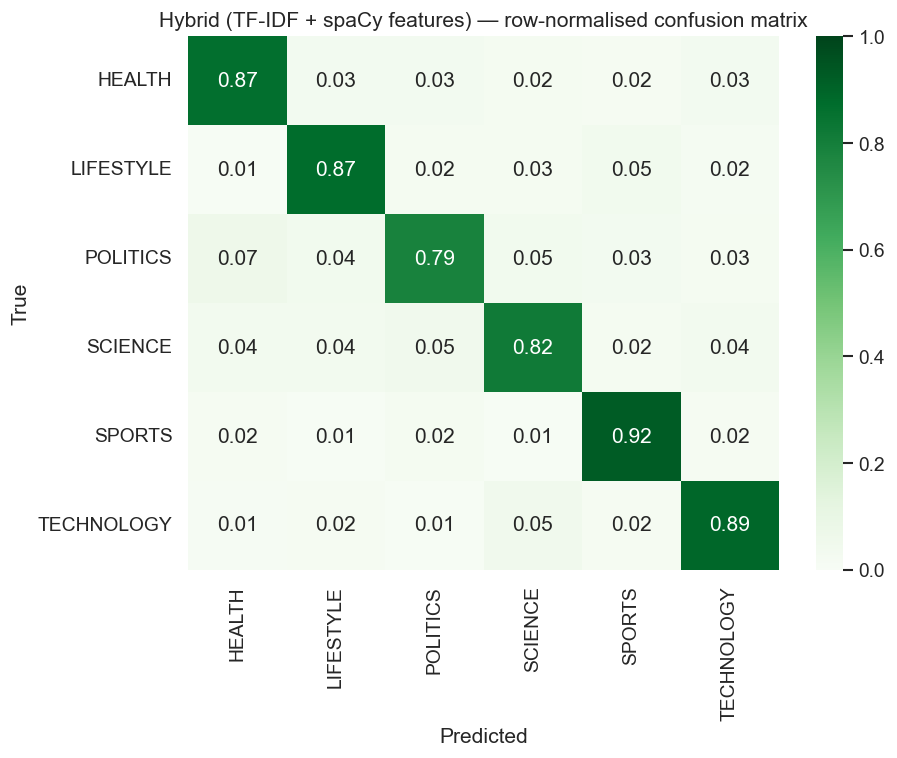

In [6]:
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    vmin=0,
    vmax=1,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Hybrid (TF-IDF + spaCy features) — row-normalised confusion matrix')
plt.tight_layout()
plt.savefig(DATA_DIR / 'day10_confusion_matrix_hybrid.png', bbox_inches='tight')
plt.show()

## 5. Day 10 summary

- **Hybrid** stacks sparse TF-IDF with **14 dense** linguistic features (NER density, POS ratios, avg token length, log sentence count).
- If macro F1 improves vs TF-IDF-only, Day 8’s entity-density EDA is paying off in a measurable way.
- **Next (Day 11):** persist the best pipeline (`joblib`), wire `train.py` / `predict.py`, and match inference preprocessing exactly.

**Tip:** For faster iteration, subsample `df_train` in the CV cell; for final numbers, use the full training set.

In [7]:
print('=' * 58)
print('  DAY 10 COMPLETE')
print('=' * 58)
print(f"  Hybrid test macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Baseline test macro F1: {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"  Figure saved: {DATA_DIR / 'day10_confusion_matrix_hybrid.png'}")
print('  Next: Day 11 — model persistence + train/predict scripts')
print('=' * 58)

  DAY 10 COMPLETE
  Hybrid test macro F1 : 0.8598
  Baseline test macro F1: 0.8661
  Figure saved: ../data/day10_confusion_matrix_hybrid.png
  Next: Day 11 — model persistence + train/predict scripts
